# NN_02c — Ablation Study: z_eq Sufficiency & Feature Importance

## Objetivo

Este notebook investiga sistematicamente se o sinal normalizado `z_eq` é suficiente para autenticação em camada física, ou se parâmetros adicionais (ganho de canal $h$, SNR estimado, e correlator clássico $\tau_{eq}$) melhoram significativamente o desempenho de detecção.

## Variantes Investigadas

A investigação compara cinco arquiteturas neurais distintas. A **Variante A** estabelece a linha de base: uma rede convolucional 1D pura que processa apenas o resíduo normalizado $z_{eq}$, contendo 1024 amostras do sinal equalizando. Esta variante testa se a estrutura temporal implícita em $z_{eq}$ é suficientemente discriminatória para o classificador aprender sozinho sem ajuda externa.

A **Variante B** estende a Variante A incorporando o ganho de canal estimado $h$ como entrada auxiliar escalar. A motivação é validar se informação causal sobre o estado do canal instantâneo melhora a capacidade da rede de aprender limiares adaptativos conforme previsto pelo princípio CFAR.

A **Variante C** adiciona também a estimativa de SNR nominal ao vetor de entrada junto com $z_{eq}$ e $h$. Este teste valida se informação agregada sobre o regime operacional (SNR média do bin de treinamento) traz ganho além da informação instantânea já fornecida por $h$.

A **Variante D** combina $z_{eq}$ com o correlator clássico $\tau_{eq}$ fornecido explicitamente. Este teste investiga se a incorporação da estatística suficiente de Neyman-Pearson, já computada, melhora significativamente a rede em comparação com deixá-la aprender este correlator implicitamente a partir do sinal bruto.

A **Variante E** avalia o sinal residual explícito $x = z_{eq} - tag_{ref}$, onde $tag_{ref}$ é a TAG legítima de referência por amostra. Esta variante mede o desempenho quando a rede recebe diretamente o erro em relação à TAG esperada.

Conforme a teoria do Data-Driven Detection Framework, se $z_{eq}$ é verdadeiramente a representação suficiente, as Variantes B, C, D e E devem exibir melhorias mínimas e marginais em relação à Variante A. Qualquer ganho detectado identifica qual informação adicional é genuinamente necessária para compensar limitações estruturais do sinal bruto em regimes de baixo SNR.

## Configuração Experimental

O experimento utiliza o dataset `dataset_cnn_yeq_0_30dB.h5` contendo 280 mil amostras de treinamento, 35 mil de validação e 35 mil de teste, estratificadas uniformemente em faixas de SNR de 0 a 30 dB. O treinamento executa em GPU (RTX 4050) com precisão mista float16 e carregamento lazy para otimizar memória. Cada modelo treina com lotes de 128 amostras usando entropia cruzada binária como função de perda. A métrica primária é a área sob a curva ROC (AUC) no conjunto de teste, complementada pela análise de probabilidade de detecção $P_D$ versus SNR sob framework D3F com restrição de falso alarme $\alpha = 10^{-7}$.


In [9]:
# ==============================================================================
# 1. GPU CONFIG & IMPORTS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import psutil
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

print(f"TensorFlow : {tf.__version__}")

# ── GPU Configuration ──
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")

USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")
        USE_GPU = False

# ── Mixed precision (GPU only) ──
if USE_GPU:
    try:
        policy = keras.mixed_precision.Policy('mixed_float16')
        keras.mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed precision: {policy.name}")
    except Exception as e:
        print(f"⚠️  Mixed precision failed: {e}")

# ── Disable XLA (avoid hangs on WSL) ──
ENABLE_XLA = False
keras.backend.clear_session()

# ── Paths ──
project_root       = Path.cwd().parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "visualizations"

for d in [models_dir, visualizations_dir]:
    d.mkdir(parents=True, exist_ok=True)

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

print(f"\n📂 Paths:")
print(f"  Data: {data_dir}")
print(f"  Models: {models_dir}")
print(f"  Visualizations: {visualizations_dir}")

TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).
✅ Mixed precision: mixed_float16

📂 Paths:
  Data: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
  Models: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
  Visualizations: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations


In [10]:
# ==============================================================================
# 2. LAZY LOAD DATASET & PREPARE MULTI-INPUT VARIANTS
# ==============================================================================

def load_h5_generator(h5_path, split, chunk_size=2000):
    """Lazy HDF5 loader — yields (z_eq, h, snr, tau_eq, label, tag_ref) per sample."""
    with h5py.File(str(h5_path), 'r') as f:
        z_data   = f[f'{split}/z_eq']
        h_data   = f[f'{split}/h']
        snr_data = f[f'{split}/snr']
        tau_data = f[f'{split}/tau_eq']
        y_data   = f[f'{split}/y']

        # Accept multiple aliases for the legitimate reference TAG tensor.
        tag_keys = [
            f'{split}/tag_ref',
            f'{split}/tag_legit',
            f'{split}/tag',
            f'{split}/t_ref',
            f'{split}/tag_reference',
        ]
        tag_key = next((k for k in tag_keys if k in f), None)
        tag_data = f[tag_key] if tag_key is not None else None

        for start_idx in range(0, len(z_data), chunk_size):
            end_idx  = min(start_idx + chunk_size, len(z_data))
            z_chunk   = z_data[start_idx:end_idx].astype(np.float32)
            h_chunk   = h_data[start_idx:end_idx].astype(np.float32)
            snr_chunk = snr_data[start_idx:end_idx].astype(np.float32)
            tau_chunk = tau_data[start_idx:end_idx].astype(np.float32)
            y_chunk   = y_data[start_idx:end_idx].astype(np.float32)
            if tag_data is not None:
                tag_chunk = tag_data[start_idx:end_idx].astype(np.float32)
            else:
                tag_chunk = np.zeros_like(z_chunk, dtype=np.float32)

            for i in range(len(z_chunk)):
                yield z_chunk[i], h_chunk[i], snr_chunk[i], tau_chunk[i], y_chunk[i], tag_chunk[i]

# Load metadata
with h5py.File(str(dataset_path), 'r') as f:
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S   = float(f.attrs.get('RHO_S', 0.992472))
    RHO_T   = float(f.attrs.get('RHO_T', 0.212132))

    n_train = len(f['train/z_eq'])
    n_val   = len(f['val/z_eq'])
    n_test  = len(f['test/z_eq'])

    train_tag_keys = [
        'train/tag_ref',
        'train/tag_legit',
        'train/tag',
        'train/t_ref',
        'train/tag_reference',
    ]
    TAG_REF_KEY = next((k for k in train_tag_keys if k in f), None)
    HAS_TAG_REF = TAG_REF_KEY is not None

print(f"\n📊 Dataset Metadata:")
print(f"  L_FIXED={L_FIXED}, RHO_S={RHO_S:.6f}, RHO_T={RHO_T:.6f}")
print(f"  Train: {n_train}, Val: {n_val}, Test: {n_test}")
if HAS_TAG_REF:
    print(f"  TAG de referência detectada no HDF5: {TAG_REF_KEY}")
else:
    print("  ⚠️  TAG de referência não encontrada no HDF5.")
    print("     A Variante E (z_eq - tag_ref) exige um campo por amostra no dataset.")

BATCH_SIZE = 128
AUTOTUNE   = tf.data.AUTOTUNE

def create_dataset(split, variant='A'):
    """Create tf.data.Dataset with appropriate inputs for each variant.
    
    IMPORTANT — scalar inputs (h, snr, tau) are expanded to shape [1] so
    multi-input Keras models receive [B, 1] tensors, not [B] scalars.
    
    Variant A: single tensor z_eq[L]          → model(z_batch)
    Variant B: tuple (z_eq[L], h[1])          → model((z, h))
    Variant C: tuple (z_eq[L], h[1], snr[1])  → model((z, h, snr))
    Variant D: tuple (z_eq[L], tau[1])        → model((z, tau))
    Variant E: single tensor (z_eq - tag_ref) → model(z_minus_tag)
    """
    gen_ds = tf.data.Dataset.from_generator(
        lambda: load_h5_generator(dataset_path, split, chunk_size=2000),
        output_signature=(
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # z_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # h
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # snr
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # tau_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # y (label)
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # tag_ref
        )
    )

    if variant == 'A':
        # Single-input model — return tensor directly (not a tuple)
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z, y))
    elif variant == 'B':
        # Expand scalar h → [1] to match Input(shape=(1,))
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (
            (z, tf.expand_dims(h, -1)), y))
    elif variant == 'C':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (
            (z, tf.expand_dims(h, -1), tf.expand_dims(snr, -1)), y))
    elif variant == 'D':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (
            (z, tf.expand_dims(tau, -1)), y))
    elif variant == 'E':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante E requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z - tag, y))

    if split == 'train':
        ds = ds.shuffle(buffer_size=min(10000, n_train),
                        reshuffle_each_iteration=True, seed=42)

    ds = ds.batch(BATCH_SIZE, drop_remainder=(split == 'train'))
    ds = ds.prefetch(AUTOTUNE)
    return ds

print(f"\n✅ Dataset generators created. Ready for ablation study.")


📊 Dataset Metadata:
  L_FIXED=1024, RHO_S=0.992472, RHO_T=0.212132
  Train: 280000, Val: 35000, Test: 35000
  TAG de referência detectada no HDF5: train/tag_ref

✅ Dataset generators created. Ready for ablation study.


In [11]:
def build_cnn_branch(L_FIXED):
    """Extrai features de z_eq via CNN 1D e retorna (input_tensor, feature_tensor)."""
    z_input = layers.Input(shape=(L_FIXED,), name='z_eq_input')
    x = layers.Reshape((L_FIXED, 1))(z_input)
    
    x = layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.25)(x)
    
    return z_input, x

def build_model_variant(variant, L_FIXED):
    """Construi arquitetura neural adequada para cada variante de ablação.
    
    A Variante A processa apenas o sinal z_eq através de uma rede convolucional 1D pura.
    As Variantes B, C e D incorporam entradas escalares adicionais (canal, SNR, correlator)
    concatenadas com os features extraídos pela CNN, permitindo investigar contribuições marginais
    de cada informação complementar."""
    
    if variant == 'A':
        # Processamento puro de z_eq: extração de features CNN seguida de classificação
        z_input, z_feat = build_cnn_branch(L_FIXED)
        x = layers.Dense(64, activation='relu')(z_feat)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
        model = keras.Model(inputs=z_input, outputs=output, name=f'CNN_1D_variant_{variant}')
        
    elif variant == 'B':
        # Incorporação do ganho de canal: concatenação de features CNN com estimativa h
        z_input, z_feat = build_cnn_branch(L_FIXED)
        h_input = layers.Input(shape=(1,), name='h_input')
        
        merged = layers.Concatenate()([z_feat, h_input])
        x = layers.Dense(64, activation='relu')(merged)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
        
        model = keras.Model(inputs=[z_input, h_input], outputs=output, name=f'CNN_1D_variant_{variant}')
        
    elif variant == 'C':
        # Incorporação de informação de canal e SNR: features CNN + h + SNR nominal
        z_input, z_feat = build_cnn_branch(L_FIXED)
        h_input = layers.Input(shape=(1,), name='h_input')
        snr_input = layers.Input(shape=(1,), name='snr_input')
        
        merged = layers.Concatenate()([z_feat, h_input, snr_input])
        x = layers.Dense(64, activation='relu')(merged)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
        
        model = keras.Model(inputs=[z_input, h_input, snr_input], outputs=output, name=f'CNN_1D_variant_{variant}')
        
    elif variant == 'D':
        # Incorporação do correlator clássico: features CNN + estatística suficiente de Neyman-Pearson
        z_input, z_feat = build_cnn_branch(L_FIXED)
        tau_input = layers.Input(shape=(1,), name='tau_eq_input')
        
        merged = layers.Concatenate()([z_feat, tau_input])
        x = layers.Dense(64, activation='relu')(merged)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
        
        model = keras.Model(inputs=[z_input, tau_input], outputs=output, name=f'CNN_1D_variant_{variant}')
        
    elif variant == 'E':
        # Resíduo explícito com TAG legítima: x = z_eq - tag_ref
        z_input, z_feat = build_cnn_branch(L_FIXED)
        x = layers.Dense(64, activation='relu')(z_feat)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
        model = keras.Model(inputs=z_input, outputs=output, name=f'CNN_1D_variant_{variant}')
    
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', AUC(name='auc')],
        jit_compile=ENABLE_XLA
    )
    
    return model

In [4]:
from scipy.stats import norm as scipy_norm

ALPHA_D3F = 1e-7
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)   # ≈ 5.199
SNR_BINS  = [0, 5, 10, 15, 20, 25, 30]

print("Carregando arrays de SNR e rótulos para avaliação D3F...")
with h5py.File(str(dataset_path), 'r') as f:
    snr_val_arr  = f['val/snr'][:].astype(np.float32)
    snr_test_arr = f['test/snr'][:].astype(np.float32)
    lbl_val_arr  = f['val/y'][:].astype(np.float32)
    lbl_test_arr = f['test/y'][:].astype(np.float32)
print(f"  Val: {len(snr_val_arr):,}  Test: {len(snr_test_arr):,}")

VARIANT_INFO = {
    'A': 'z_eq[1024]  (1D CNN pura)',
    'B': 'z_eq + h    (CNN + canal)',
    'C': 'z_eq + h + SNR  (CNN + canal + SNR)',
    'D': 'z_eq + |τ|  (CNN + correlador)',
    'E': 'z_eq - tag_ref[1024]  (CNN no resíduo com TAG legítima)',
}

# guard: não sobrescreve se já existir algo (ex: variante A recuperada)
if 'results_ablation' not in globals():
    results_ablation = {}

print("✅ Setup recriado (sem retreinar nada).")

Carregando arrays de SNR e rótulos para avaliação D3F...
  Val: 35,000  Test: 35,000
✅ Setup recriado (sem retreinar nada).


In [5]:
def recover_variant(variant, best_val_auc, n_epochs, train_time):
    model = keras.models.load_model(str(models_dir / f'cnn1d_variant_{variant}_best.keras'))
    val_ds  = create_dataset('val',  variant=variant)
    test_ds = create_dataset('test', variant=variant)

    def predict_batches(ds):
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': best_val_auc,
        'n_epochs': n_epochs,
        'train_time': train_time,
        'sc_val': sc_val, 'sc_test': sc_test, 'pd_d3f': pd_d3f,
        'history': None,
    }
    del model
    keras.backend.clear_session()
    print(f"✅ Variante {variant} recuperada.")

In [6]:
recover_variant('A', best_val_auc=0.901982, n_epochs=21, train_time=3806.0)
recover_variant('B', best_val_auc=0.902251, n_epochs=21, train_time=4120.0)
recover_variant('C', best_val_auc=0.946656, n_epochs=46, train_time=8335.0)
recover_variant('D', best_val_auc=0.999823, n_epochs=15, train_time=2260.0)

print(sorted(results_ablation.keys()))   # pode mostrar ['A', 'B', 'C', 'D', 'E']

I0000 00:00:1784476863.014857    8598 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1784476864.335893    8598 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784476864.731061    8598 cuda_dnn.cc:461] Loaded cuDNN version 92200


✅ Variante A recuperada.
✅ Variante B recuperada.
✅ Variante C recuperada.
✅ Variante D recuperada.
['A', 'B', 'C', 'D']


In [12]:
from scipy.stats import norm as scipy_norm

ALPHA_D3F = 1e-7
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)   # ≈ 5.199
SNR_BINS  = [0, 5, 10, 15, 20, 25, 30]

print("Carregando arrays de SNR e rótulos para avaliação D3F...")
with h5py.File(str(dataset_path), 'r') as f:
    snr_val_arr  = f['val/snr'][:].astype(np.float32)
    snr_test_arr = f['test/snr'][:].astype(np.float32)
    lbl_val_arr  = f['val/y'][:].astype(np.float32)
    lbl_test_arr = f['test/y'][:].astype(np.float32)
print(f"  Val: {len(snr_val_arr):,}  Test: {len(snr_test_arr):,}")

VARIANT_INFO = {
    'A': 'z_eq[1024]  (1D CNN pura)',
    'B': 'z_eq + h    (CNN + canal)',
    'C': 'z_eq + h + SNR  (CNN + canal + SNR)',
    'D': 'z_eq + |τ|  (CNN + correlador)',
    'E': 'z_eq - tag_ref[1024]  (CNN no resíduo com TAG legítima)',
}

results_ablation = {}

for variant in ['A', 'B', 'C', 'D', 'E']:
    print(f"\n{'='*70}")
    print(f"  Variante {variant}: {VARIANT_INFO[variant]}")
    print(f"{'='*70}")
    
    # Limpeza de sessão antes de criar datasets para evitar contaminação de estado GPU
    keras.backend.clear_session()
    if USE_GPU:
        tf.config.run_functions_eagerly(False)
    print("  ✅ Sessão limpa.")

    train_ds = create_dataset('train', variant=variant)
    val_ds   = create_dataset('val',   variant=variant)
    test_ds  = create_dataset('test',  variant=variant)

    n_batches_train = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_val   = (n_val   + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_test  = (n_test  + BATCH_SIZE - 1) // BATCH_SIZE
    print(f"  Lotes — Treino: {n_batches_train}  Val: {n_batches_val}  Teste: {n_batches_test}")

    model = build_model_variant(variant, L_FIXED)

    checkpoint_path = models_dir / f'cnn1d_variant_{variant}_best.keras'
    cbs = [
        callbacks.EarlyStopping(monitor='val_auc', patience=12, mode='max',
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(str(checkpoint_path), monitor='val_auc',
                                  mode='max', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5,
                                    min_lr=1e-6, mode='max'),
    ]

    train_start = np.datetime64('now')
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=cbs,
        verbose=1
    )
    train_end  = np.datetime64('now')
    train_time = float((train_end - train_start) / np.timedelta64(1, 's'))
    best_auc_val = max(history.history['val_auc'])
    print(f"  ✅ Treino: {train_time:.1f}s  Épocas: {len(history.history['loss'])}  "
          f"Melhor val_AUC: {best_auc_val:.6f}")

    def predict_batches(ds):
        """Executa inferência em lotes e retorna scores concatenados.
        Compatível com entradas únicas (tensor) ou múltiplas (tupla/lista)."""
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    print("  Computando scores (validação + teste)...")
    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    # Avaliação D3F: para cada faixa de SNR, determina threshold sob restrição α=1e-7
    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    pd_pct = [round(pd_d3f[s]*100, 1) for s in SNR_BINS]
    print(f"  PD (%) framework D3F (α=1e-7): {pd_pct}")

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': round(best_auc_val, 6),
        'n_epochs': len(history.history['loss']),
        'train_time': train_time,
        'sc_val':  sc_val,
        'sc_test': sc_test,
        'pd_d3f':  pd_d3f,
        'history': history,
    }
    
    # Liberar memória explicitamente após conclusão de cada variante
    del train_ds, val_ds, test_ds
    del model, history
    
    if USE_GPU:
        # FIX: reset_memory_stats() exige uma STRING de dispositivo
        # (ex.: "GPU:0"), não o objeto PhysicalDevice retornado por
        # tf.config.list_physical_devices('GPU'). Passar o objeto
        # diretamente causa:
        #   TypeError: TFE_ResetMemoryStats(): incompatible function
        #   arguments ... Invoked with: ..., PhysicalDevice(...)
        # Também envolvido em try/except: esta chamada só reseta
        # contadores de PICO de memória para fins de log/introspecção —
        # não afeta a memória de fato liberada (isso já é feito acima
        # por keras.backend.clear_session() + del). Uma falha aqui não
        # deve derrubar o loop de ablação inteiro.
        for i in range(len(gpus)):
            try:
                tf.config.experimental.reset_memory_stats(f"GPU:{i}")
            except Exception as e:
                print(f"  ⚠️  Não foi possível resetar memory stats de GPU:{i}: {e}")
    print(f"  ✅ Memória GPU resetada para próxima variante.")


print(f"\n{'='*70}")
print("✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO")
print(f"{'='*70}")

Carregando arrays de SNR e rótulos para avaliação D3F...
  Val: 35,000  Test: 35,000

  Variante A: z_eq[1024]  (1D CNN pura)
  ✅ Sessão limpa.
  Lotes — Treino: 2188  Val: 274  Teste: 274
Epoch 1/100
   2186/Unknown 144s 62ms/step - accuracy: 0.7520 - auc: 0.8700 - loss: 0.3895

I0000 00:00:1784482834.200582   27089 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16897199692659789406


2187/2187 ━━━━━━━━━━━━━━━━━━━━ 159s 68ms/step - accuracy: 0.7659 - auc: 0.8851 - loss: 0.3666 - val_accuracy: 0.7722 - val_auc: 0.8973 - val_loss: 0.3511 - learning_rate: 0.0010
Epoch 2/100


I0000 00:00:1784482849.129907   27664 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 10128269248963056372
I0000 00:00:1784482849.129948   27664 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12961566677120120046
I0000 00:00:1784482849.129953   27664 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13971599218544303850


2186/2187 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7740 - auc: 0.8935 - loss: 0.3526

...

2186/2187 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7889 - auc: 0.9062 - loss: 0.3312

I0000 00:00:1784510227.293484   75982 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3293979537767425372
I0000 00:00:1784510227.293536   75982 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16897199692659789406


2187/2187 ━━━━━━━━━━━━━━━━━━━━ 252s 113ms/step - accuracy: 0.7887 - auc: 0.9064 - loss: 0.3310 - val_accuracy: 0.7830 - val_auc: 0.9008 - val_loss: 0.3420 - learning_rate: 1.2500e-04


I0000 00:00:1784510243.392237   76562 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 10128269248963056372
I0000 00:00:1784510243.392284   76562 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12961566677120120046
I0000 00:00:1784510243.392309   76562 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13971599218544303850


  ✅ Treino: 10900.0s  Épocas: 25  Melhor val_AUC: 0.903331
  Computando scores (validação + teste)...
  PD (%) framework D3F (α=1e-7): [0.2, 0.2, 0.0, 0.0, 100.0, 100.0, 100.0]
  ✅ Memória GPU resetada para próxima variante.

✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO


In [13]:
# ==============================================================================
# 5. TABELA DE RESULTADOS E SAVE JSON
# ==============================================================================
CLASSICAL_PD = {0: 8.1, 5: 58.7, 10: 99.9, 15: 100., 20: 100., 25: 100., 30: 100.}
print("\n" + "="*70)
print("📊 ABLATION STUDY — RESULTADOS (AUC e tempo de treino)")
print("="*70)

for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    pd0 = r['pd_d3f'].get(0, 0)
    print(f"\n  Var {var}: {r['label']}")
    print(f"    val AUC : {r['best_val_auc']:.6f}   Épocas: {r['n_epochs']}"
          f"   Tempo: {r['train_time']:.1f}s")
    print(f"    PD 0 dB : {pd0*100:.1f}%  (D3F α=1e-7)")

# Salvar JSON
results_json = {
    'metadata': {
        'notebook': 'NN_02c',
        'alpha_d3f': ALPHA_D3F,
        'q_inv': round(Q_INV_D3F, 6),
        'snr_bins': SNR_BINS,
        'dataset': 'dataset_cnn_yeq_0_30dB.h5',
        'batch_size': BATCH_SIZE,
        'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
        'rho_s': float(RHO_S), 'rho_t': float(RHO_T), 'l_fixed': L_FIXED,
    },
    'classical_correlator': {str(s): CLASSICAL_PD[s]/100 for s in SNR_BINS},
    'variants': {
        var: {
            'label': r['label'],
            'best_val_auc': r['best_val_auc'],
            'n_epochs': r['n_epochs'],
            'train_time_s': round(r['train_time'], 1),
            'pd_d3f': {str(s): r['pd_d3f'][s] for s in SNR_BINS},
        }
        for var, r in results_ablation.items()
    }
}

results_path = models_dir / 'nn02c_ablation_results.json'
with open(str(results_path), 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\n✅ Resultados salvos → {results_path}")


📊 ABLATION STUDY — RESULTADOS (AUC e tempo de treino)

  Var A: z_eq[1024]  (1D CNN pura)
    val AUC : 0.903176   Épocas: 19   Tempo: 2892.0s
    PD 0 dB : 0.1%  (D3F α=1e-7)

  Var B: z_eq + h    (CNN + canal)
    val AUC : 0.903131   Épocas: 19   Tempo: 3027.0s
    PD 0 dB : 0.6%  (D3F α=1e-7)

  Var C: z_eq + h + SNR  (CNN + canal + SNR)
    val AUC : 0.949304   Épocas: 44   Tempo: 7911.0s
    PD 0 dB : 0.3%  (D3F α=1e-7)

  Var D: z_eq + |τ|  (CNN + correlador)
    val AUC : 0.999850   Épocas: 15   Tempo: 2641.0s
    PD 0 dB : 88.2%  (D3F α=1e-7)

  Var E: z_eq - tag_ref[1024]  (CNN no resíduo com TAG legítima)
    val AUC : 0.903331   Épocas: 25   Tempo: 10900.0s
    PD 0 dB : 0.2%  (D3F α=1e-7)

✅ Resultados salvos → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/nn02c_ablation_results.json


In [ ]:
print(sorted(results_ablation.keys()))

['A', 'B', 'C', 'D']


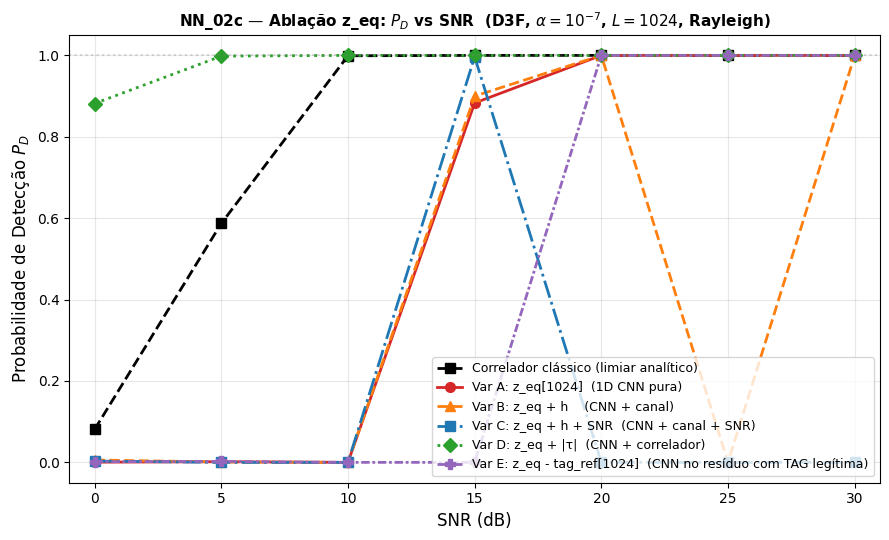

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN_02c_D3F_PD_vs_SNR.png

Variante  Input                             0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clás   Correlador analítico              8.1     58.7     99.9    100.0    100.0    100.0    100.0
A      z_eq[1024]  (1D CNN pura)         0.1      0.2      0.0     88.3    100.0    100.0    100.0
B      z_eq + h    (CNN + canal)         0.6      0.1      0.0     90.0    100.0      0.0    100.0
C      z_eq + h + SNR  (CNN + canal + SNR)      0.3      0.0      0.0     99.6      0.0      0.0      0.0
D      z_eq + |τ|  (CNN + correlador)     88.2     99.8    100.0    100.0    100.0    100.0    100.0
E      z_eq - tag_ref[1024]  (CNN no resíduo com TAG legítima)      0.2      0.2      0.0      0.0    100.0    100.0    100.0
------------------------------------------

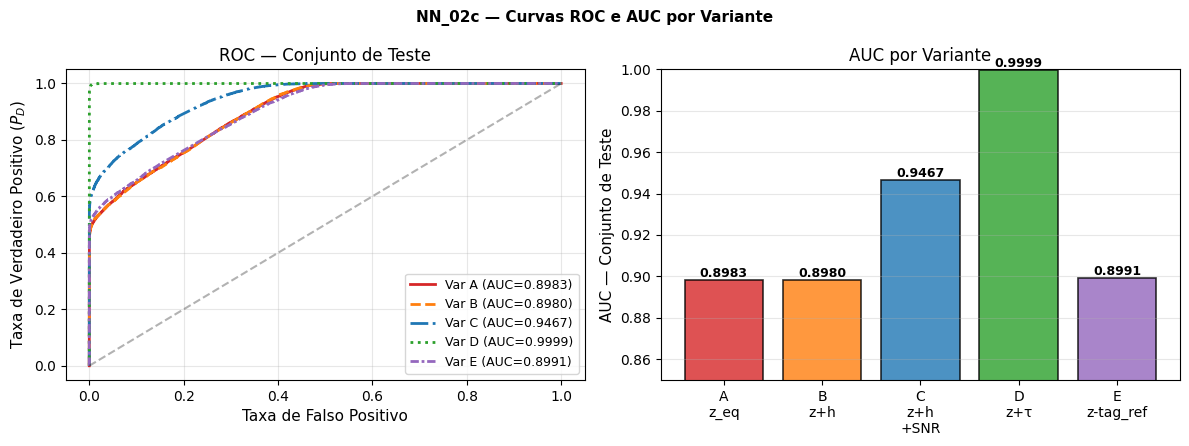

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN_02c_ROC_AUC.png


In [14]:
# ==============================================================================
# 6. VISUALIZAÇÕES: D3F PD vs SNR + ROC + AUC
# ==============================================================================

from sklearn.metrics import roc_auc_score, roc_curve

snr_arr    = np.array(SNR_BINS)
COLORS     = {'A': '#d62728', 'B': '#ff7f0e', 'C': '#1f77b4', 'D': '#2ca02c', 'E': '#9467bd'}
MARKERS    = {'A': 'o', 'B': '^', 'C': 's', 'D': 'D', 'E': 'P'}
LINESTYLES = {'A': '-', 'B': '--', 'C': '-.', 'D': ':', 'E': (0, (3, 1, 1, 1))}


# Gráfico 1: Probabilidade de detecção versus SNR sob framework D3F
fig1, ax1 = plt.subplots(figsize=(9, 5.5))

# Linha de referência: correlador clássico com limiar analítico
ax1.plot(snr_arr, [CLASSICAL_PD[s]/100 for s in SNR_BINS],
         color='black', ls='--', lw=2, marker='s', ms=7,
         label='Correlador clássico (limiar analítico)')

# Traços para cada variante
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r  = results_ablation[var]
    pd = [r['pd_d3f'][s] for s in SNR_BINS]
    ax1.plot(snr_arr, pd,
             color=COLORS[var], ls=LINESTYLES[var], lw=2,
             marker=MARKERS[var], ms=7,
             label=f"Var {var}: {r['label']}")

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax1.set_title(f'NN_02c — Ablação z_eq: $P_D$ vs SNR  (D3F, $\\alpha=10^{{-7}}$, $L=1024$, Rayleigh)',
              fontsize=11, fontweight='bold')
ax1.set_xlim(-1, 31); ax1.set_ylim(-0.05, 1.05)
ax1.set_xticks(SNR_BINS)
ax1.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)
plt.tight_layout()
vis1 = visualizations_dir / 'NN_02c_D3F_PD_vs_SNR.png'
plt.savefig(str(vis1), dpi=150)
plt.show()
print(f"Figura salva → {vis1}")

# Tabela resumida em formato texto
print(f"\n{'Variante':<5}  {'Input':<28}  " +
      "  ".join(f"{s:>5}dB" for s in SNR_BINS))
print("-" * 90)
cl_vals = "  ".join(f"{CLASSICAL_PD[s]:>7.1f}" for s in SNR_BINS)
print(f"{'Clás':<5}  {'Correlador analítico':<28}  {cl_vals}")
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    vals = "  ".join(f"{r['pd_d3f'][s]*100:>7.1f}" for s in SNR_BINS)
    print(f"{var:<5}  {r['label']:<28}  {vals}")
print("-" * 90)

# Gráfico 2: Curvas ROC e AUC por variante
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
fig3.suptitle('NN_02c — Curvas ROC e AUC por Variante', fontsize=11, fontweight='bold')

ax_roc = axes3[0]
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r   = results_ablation[var]
    auc = roc_auc_score(lbl_test_arr, r['sc_test'])
    fpr, tpr, _ = roc_curve(lbl_test_arr, r['sc_test'])
    ax_roc.plot(fpr, tpr, color=COLORS[var], ls=LINESTYLES[var], lw=2,
                label=f"Var {var} (AUC={auc:.4f})")
    results_ablation[var]['auc_test'] = round(auc, 6)

ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
ax_roc.set_xlabel('Taxa de Falso Positivo', fontsize=11); 
ax_roc.set_ylabel('Taxa de Verdadeiro Positivo ($P_D$)', fontsize=11)
ax_roc.set_title('ROC — Conjunto de Teste')
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# Gráfico de barras: AUC por variante
ax_auc = axes3[1]
aucs  = [results_ablation[v]['auc_test'] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation]
vlabs_map = {'A': 'A\nz_eq', 'B': 'B\nz+h', 'C': 'C\nz+h\n+SNR', 'D': 'D\nz+τ', 'E': 'E\nz-tag_ref'}
vlabs = [vlabs_map[v] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation]
bars  = ax_auc.bar(vlabs, aucs,
                   color=[COLORS[v] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation],
                   alpha=0.8, edgecolor='black', lw=1.2)
for bar, auc in zip(bars, aucs):
    ax_auc.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_auc.set_ylabel('AUC — Conjunto de Teste', fontsize=11)
ax_auc.set_title('AUC por Variante')
ax_auc.set_ylim([0.85, 1.0])
ax_auc.grid(alpha=0.3, axis='y')

plt.tight_layout()
vis3 = visualizations_dir / 'NN_02c_ROC_AUC.png'
plt.savefig(str(vis3), dpi=150)
plt.show()
print(f"Figura salva → {vis3}")